In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# path = 'P:\\Lukas_Gehrke\\NAH\\behavior\\5_single-subject-EEG-analysis'
path = '/Users/lukasgehrke/data/NAH/data/5_single-subject-EEG-analysis/'
fname = 'behavior_all.csv'

df = pd.read_csv(path + fname, delimiter=';')

                     mean       std
hapticProfile                      
baseline         1.367728  0.509120
sound            1.419241  0.625464
vibration        1.359545  0.540551
vibration+sound  1.273852  0.444628


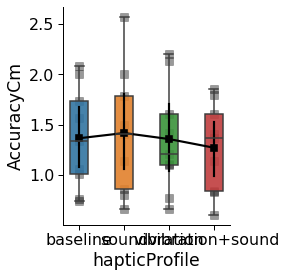

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


In [15]:
df = df[df.bad_epoch != 1]

df = df.groupby(['hapticProfile','id']).mean().reset_index()

# y = 'answerID'
# title = 'answerID'

y = 'AccuracyCm'
title = 'AccuracyCm'

# y = 'fix_delay'

print(df.groupby('hapticProfile')[y].agg(['mean','std']))

with sns.plotting_context('paper', font_scale = 1.8):

    ### Create new plot
    fig, ax = plt.subplots(1, 1, figsize=(3,4))
    fig.patch.set_alpha(1)

    sns.despine() #bottom=True, left=True

    # Plot the orbital period with horizontal boxes
    # sns.boxplot(x=x, y=y, behavior=behavior, whis=[0, 100], width=.3, order= ['intention','involuntary','augmented'], palette=palette, linewidth=1)

    # Add in points to show each observation
    # sns.stripplot(x=x, y=y, behavior=behavior, size=6, palette=palette, linewidth=1, dodge='auto', legend=None)

    # show boxplots
    ax = sns.boxplot(data = df, x = 'hapticProfile', y = y, order= ['baseline','sound','vibration','vibration+sound'], width=.4, hue='hapticProfile', linewidth=1.5)
    for patch in ax.patches: # adapt alpha
            r, g, b, a = patch.get_facecolor()
            patch.set_facecolor((r, g, b, .9))

    # show line connecting means
    ax =  sns.pointplot(data = df, x = 'hapticProfile', y = y, markers="s" ,color = 'black', order= ['baseline','sound','vibration','vibration+sound'])
        
    #  show lines connecting pid means observations    
    # ax = sns.lineplot(data = df, x = 'hapticProfile', y = y, hue = id, palette = sns.color_palette(['black'],8),legend = False,alpha=0.4)
    
    ax = sns.scatterplot(data = df, x = 'hapticProfile', y = y, s=50, legend= True, marker="s",color = 'black',edgecolor = 'black',alpha=0.4)
        
    # ax.invert_yaxis()
    # add_stat_annotation(ax, behavior=behavior_means, x=x, y=y, box_pairs=[("baseline", "ems_random"), ("baseline", "ems_bci"), ('ems_random', 'ems_bci')], test='t-test_paired', text_format='star', loc='outside', verbose=2)

    handles, labels = ax.get_legend_handles_labels()  
    
    #plt.legend(handles[3:6],labels[3:6],frameon=True,loc = 'upper left',labelspacing =0.3)

    # set ylimit
    # ax.set_ylim(-450,150)
    
    # label_plot_for_subcats(ax)
    # ax.set_title(title)
    # ax.set_ylabel(ylabel)
    # ax.set_xlabel(xlabel)
    
    plt.show()

    fig.savefig(title + '.eps', format='eps', transparent=True, bbox_inches='tight', dpi=300)
    fig.savefig(title + '.svg', format='svg', transparent=True, bbox_inches='tight', dpi=300)
    fig.savefig(title + '.png', format='png', transparent=True, bbox_inches='tight', dpi=300)

In [16]:
import pymer4 as pymer4
from pymer4.models import Lmer

full_model = Lmer(y + " ~ hapticProfile + (1|id)", data = df)
display(full_model.fit(REML = False))

null_model = Lmer(y + " ~ (1|id)", data = df)
display(null_model.fit(REML = False))

pymer4.stats.lrt([null_model,full_model])

Linear mixed model fit by maximum likelihood  ['lmerMod']
Formula: AccuracyCm~hapticProfile+(1|id)

Family: gaussian	 Inference: parametric

Number of observations: 36	 Groups: {'id': 9.0}

Log-likelihood: 1.269 	 AIC: 9.462

Random effects:

                 Name    Var    Std
id        (Intercept)  0.232  0.482
Residual               0.021  0.145

No random effect correlations specified

Fixed effects:



,Estimate,2.5_ci,97.5_ci,SE,DF,T-stat,P-val,Sig
(Intercept),1.368,1.039,1.697,0.168,10.221,8.151,0.000,***
hapticProfilesound,0.052,-0.083,0.186,0.068,27.000,0.753,0.458,
hapticProfilevibration,-0.008,-0.142,0.126,0.068,27.000,-0.120,0.906,
hapticProfilevibration+sound,-0.094,-0.228,0.040,0.068,27.000,-1.373,0.181,


Linear mixed model fit by maximum likelihood  ['lmerMod']
Formula: AccuracyCm~(1|id)

Family: gaussian	 Inference: parametric

Number of observations: 36	 Groups: {'id': 9.0}

Log-likelihood: -0.880 	 AIC: 7.759

Random effects:

                 Name    Var    Std
id        (Intercept)  0.231  0.481
Residual               0.025  0.157

No random effect correlations specified

Fixed effects:



,Estimate,2.5_ci,97.5_ci,SE,DF,T-stat,P-val,Sig
(Intercept),1.355,1.037,1.674,0.162,9.0,8.34,0.0,***


,model,npar,AIC,BIC,log-likelihood,deviance,Chisq,Df,P-val,Sig
0,AccuracyCm~(1|id),3,7.759259,12.509816,-0.879630,1.759259,,,,
1,AccuracyCm~hapticProfile+(1|id),6,9.461928,18.963042,1.269036,-2.538072,4.297331,3.0,0.231096,
